In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

In [2]:
# Define the path to the directory containing the CSV files
path = '/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/stair_collab/julie_temperature/' # Use your actual path

# Get a list of all CSV file names in the directory
all_files = glob.glob(os.path.join(path, "stats_*.csv"))

# Create an empty list to store individual DataFrames
df_list = []

# Loop through each file, read it into a DataFrame, and append to the list
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
df_master = pd.concat(df_list, axis=0, ignore_index=True)

In [3]:
site_names = list(np.unique(df_master.site_name))

In [4]:
df_master['abs_bias'] = np.abs(df_master['bias'])

In [5]:
df_mean = df_master[['depth', 'rmse', 'abs_bias']].groupby('depth').mean()

Text(0, 0.5, 'RMSE [deg C]')

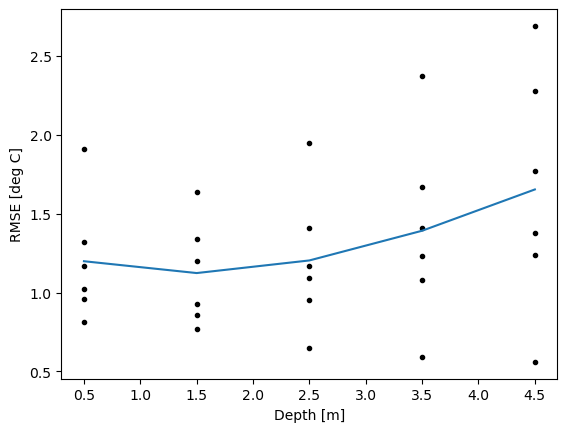

In [13]:
for name in site_names:
    select = df_master[df_master['site_name'] == name]
    plt.plot(select.depth, select.rmse, 'k.')

plt.plot(df_mean.index, df_mean.rmse)
plt.xlabel('Depth [m]')
plt.ylabel('RMSE [deg C]')

Text(0, 0.5, 'Bias Absolute Value [deg C]')

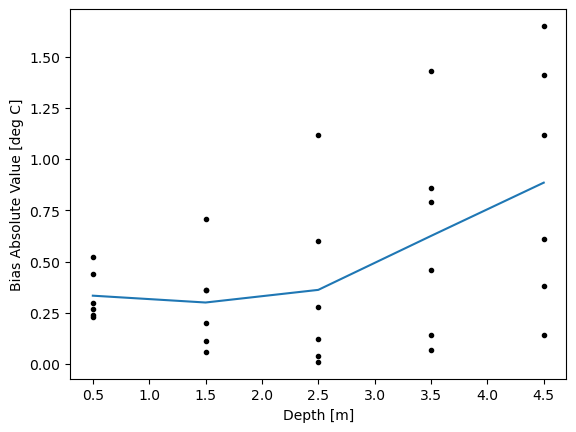

In [12]:
for name in site_names:
    select = df_master[df_master['site_name'] == name]
    plt.plot(select.depth, select.abs_bias, 'k.')

plt.plot(df_mean.index, df_mean.abs_bias)
plt.xlabel('Depth [m]')
plt.ylabel('Bias Absolute Value [deg C]')